# Detecção de Círculos em Imagens

Neste projeto, será implementado um sistema de detecção automática de círculos em uma
imagem fornecida (circulos_1.png). A detecção será baseada no reconhecimento da forma
circular, aplicando técnicas de pré-processamento, suavização e realce de bordas. O objetivo é
identificar todos os círculos presentes na imagem, destacá-los visualmente e exibir a contagem
final de objetos detectados.

In [45]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('../')  

import funcoes 

import importlib
importlib.reload(funcoes)



<module 'funcoes' from 'c:\\Users\\dalto\\OneDrive\\Documentos\\Unifor\\Semestre 8\\ProcessamentoDigitalImagem\\AV2\\Projeto2_Deteccao_Circulos\\..\\funcoes.py'>

In [46]:
# Carrega a imagem
img1_cinza = funcoes.carregar_imagem("circulos_1.png")
img1_rbg = funcoes.carregar_imagem("circulos_1.png", "rgb")

img2_cinza = img1_cinza.copy()



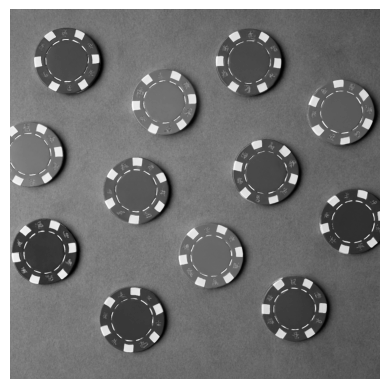

In [ ]:
# Aplicando o filtro

imagem_mediana = cv2.medianBlur(img2_cinza, 3)


plt.imshow(imagem_mediana,cmap="gray")
plt.axis('off')
plt.show()

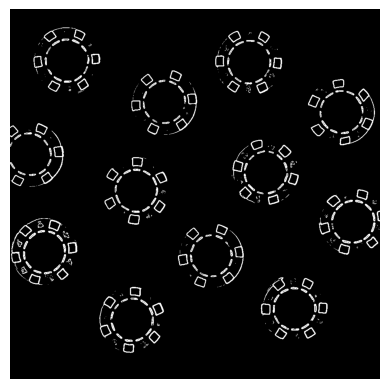

In [48]:

# Manipulando bordas da imagem com tratamento da Mediana

sobel_x = cv2.Sobel(imagem_mediana, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(imagem_mediana, cv2.CV_64F, 0, 1, ksize=5)


sobel_mag = cv2.magnitude(sobel_x, sobel_y)


sobel_mag_normalizada = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX)
sobel_mag_normalizada = sobel_mag_normalizada.astype(np.uint8)

# Binarização das Bordas em Sobel
     
_, sobel_bin = cv2.threshold(sobel_mag_normalizada, 50, 255, cv2.THRESH_BINARY)

plt.imshow(sobel_bin, cmap= 'gray')
plt.axis('off')
plt.show()



In [ ]:
# Identificar Circulos com o HOUGH CIRCLES

circulos = cv2.HoughCircles(sobel_bin, cv2.HOUGH_GRADIENT, dp=1.1, minDist=200, param1=200, param2=40, minRadius=25, maxRadius=90)
circulos = np.uint16(np.around(circulos))

circulos_imagem = img1_rbg.copy()
for i in circulos[0,:]:
    cv2.circle(circulos_imagem,(i[0],i[1]),i[2],(0,255,0),2)



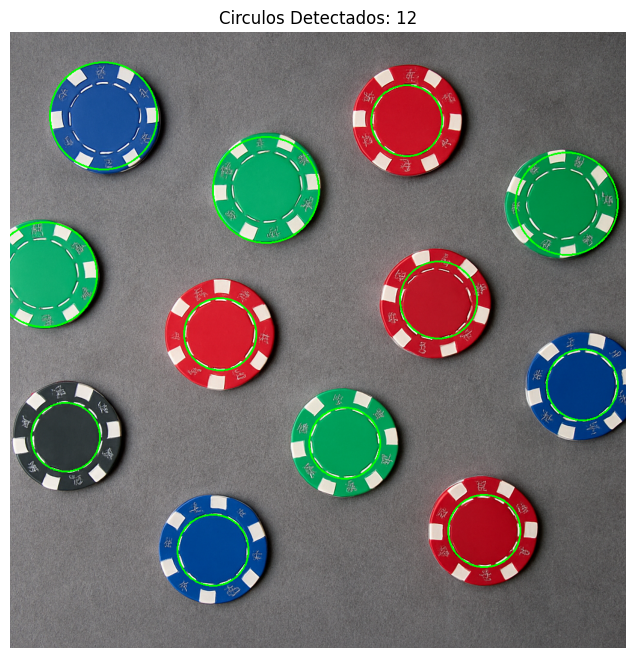

In [50]:
# Contagem de Circulos


plt.figure(figsize=(12, 8))

funcoes.exibir_imagem(circulos_imagem, f"Circulos Detectados: {len(circulos[0])}")

plt.show()
